In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/test.csv
/kaggle/input/sample_submission.csv.zip
/kaggle/input/description.md
/kaggle/input/train.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/train.csv
/kaggle/input/sample_submission.csv
/kaggle/input/us-patent-phrase-to-phrase-matching/test.csv
/kaggle/input/us-patent-phrase-to-phrase-matching/sample_submission.csv.zip
/kaggle/input/us-patent-phrase-to-phrase-matching/description.md
/kaggle/input/us-patent-phrase-to-phrase-matching/train.csv.zip
/kaggle/input/us-patent-phrase-to-phrase-matching/test.csv.zip
/kaggle/input/us-patent-phrase-to-phrase-matching/train.csv
/kaggle/input/us-patent-phrase-to-phrase-matching/sample_submission.csv


In [3]:
train = pd.read_csv("/kaggle/input/us-patent-phrase-to-phrase-matching/train.csv")
test = pd.read_csv("/kaggle/input/us-patent-phrase-to-phrase-matching/test.csv")
submission = pd.read_csv("/kaggle/input/us-patent-phrase-to-phrase-matching/sample_submission.csv")


In [4]:
train


,id,anchor,target,context,score
0,378b8322a01b88db,obstacle course,obstacle position trajectory,B60,0.50
1,f43c824b3d939294,hardware blocks,housing,G06,0.25
2,c4ef1b4f79424269,collator,collation apparatus,H04,0.75
3,f8702c95bfa192fe,engage clamp,disconnect clamp,H01,0.25
4,5c24dd3361ba190d,oven batteries,batteries,C10,0.50
...,...,...,...,...,...
32820,29681528e21b1e92,movement directions,blood flow direction in human body,B60,0.00
32821,43b410ed284a43ff,storage lid,roof,B60,0.25
32822,9485e59513ccd389,shielded conductor,shielding ignition cable,H01,0.50
32823,fe252fe7819c9bcd,normal base,driving piston,B41,0.25


In [5]:
test


,id,anchor,target,context
0,2a988c7d98568627,project onto surface,disposing,G03
1,75a3ae03b26e2f7e,rotate on its longitudinal axis,gear grinding device,B24
2,0126c870aede9858,combine with optical elements,metal elements,G11
3,2cf662e1cc9b354e,obstacle course,environment,B60
4,8dfee5874de0b408,move to range,stop moving,F15
...,...,...,...,...
3643,cae11dc44884651a,triethylammonium salt,pharmaceutical salt,C07
3644,fa4261ac9c6775dd,top surface member,member top wall,H01
3645,a6d6f5c6e01479c2,moisture proof film,transparent moisture proof films,H05
3646,6a1544f5cf0e3520,tap portion,tap,A61


In [6]:
submission


,id,score
0,2a988c7d98568627,0
1,75a3ae03b26e2f7e,0
2,0126c870aede9858,0
3,2cf662e1cc9b354e,0
4,8dfee5874de0b408,0
...,...,...
3643,cae11dc44884651a,0
3644,fa4261ac9c6775dd,0
3645,a6d6f5c6e01479c2,0
3646,6a1544f5cf0e3520,0


/tmp/ipykernel_11/3609451108.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train.score)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='score', ylabel='Density'>

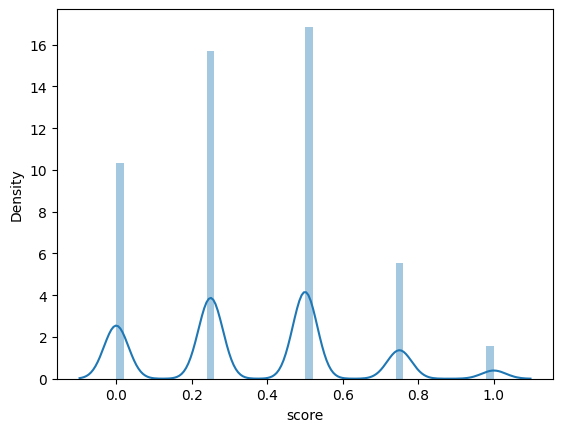

In [7]:
sns.distplot(train.score)


{'whiskers': [<matplotlib.lines.Line2D at 0x7fff9bc43c90>,
 'caps': [<matplotlib.lines.Line2D at 0x7fff9bc510d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fff9b9eba90>],
 'medians': [<matplotlib.lines.Line2D at 0x7fff9bc51f90>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fff9c5b26d0>],
 'means': []}

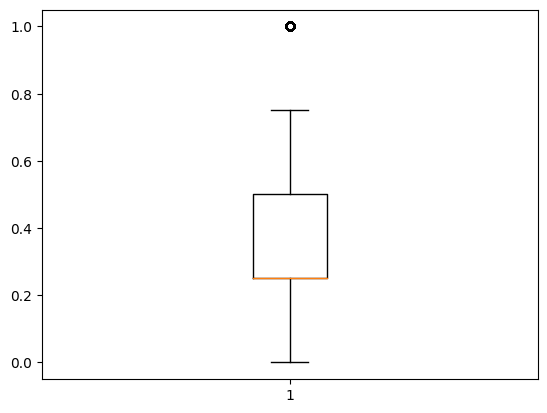

In [8]:
plt.boxplot(train.score)


In [9]:
target = train.score


In [10]:
combi = train.drop(['score'], axis=1).append(test)
combi


AttributeError: 'DataFrame' object has no attribute 'append'

In [11]:
y = target
X = combi[: len(train)]
X_test = combi[len(train) :]


NameError: name 'combi' is not defined

In [12]:
import nltk, string
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=1,stop_words='english')

def cosine_sim(text1, text2):
    tfidf = vectorizer.fit_transform([text1, text2])
    return ((tfidf * tfidf.T).A)[0,1]

simularity = []

for i in range(len(X_test)):
    
    anchor = X_test['anchor'][i]
    test_target = X_test['target'][i]
    
    cosine_similarity = cosine_sim(anchor, test_target)
    
    simularity.append(cosine_similarity)
    
print(len(simularity))
print(simularity)


NameError: name 'X_test' is not defined

In [13]:
submission['score'] = simularity
submission.to_csv("submission.csv", index=False)
submission


ValueError: Length of values (0) does not match length of index (3648)